## Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Exploratory Data Analysis - Netflix Dataset

In [5]:
# Path to your file in Drive
file_path = "/content/netflix_dataset.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="netflix_dataset"
)

print(df.shape)
print("-------")
print(df.info())
print("-------")
df.head()

(7787, 12)
-------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7281 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB
None
-------


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,0.03,NaN,"Jo√£o Miguel, Bianca Comparato, Michel Gomes, ...",Brazil,2020-08-14 00:00:00,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19:00,Jorge Michel Grau,"Demi√°n Bichir, H√©ctor Bonilla, Oscar Serrano...",Mexico,2016-12-23 00:00:00,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59:00,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20 00:00:00,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16 00:00:00,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01 00:00:00,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [6]:
#Identify the missing values

temp = df.isnull().sum()
uniq = pd.DataFrame({'Columns': temp.index, 'Missing values': temp.values})
uniq

,Columns,Missing values
0,show_id,0
1,type,0
2,title,0
3,director,2389
4,cast,718
5,country,506
6,date_added,10
7,release_year,0
8,rating,7
9,duration,0


### Analysis of Netflix Movies

In [7]:
netflix_movies = df[df['type']=='Movie']
netflix_movies

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,Movie,07:19:00,Jorge Michel Grau,"Demi√°n Bichir, H√©ctor Bonilla, Oscar Serrano...",Mexico,2016-12-23 00:00:00,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59:00,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20 00:00:00,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16 00:00:00,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01 00:00:00,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...
6,s7,Movie,122,Yasir Al Yasiri,"Amina Khalil, Ahmed Dawood, Tarek Lotfy, Ahmed...",Egypt,2020-06-01 00:00:00,2019,TV-MA,95 min,"Horror Movies, International Movies","After an awful accident, a couple admitted to ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
7781,s7782,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11 00:00:00,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...",2020-10-19 00:00:00,2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02 00:00:00,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,2020-09-25 00:00:00,2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."


#### Year wise Analysis

/tmp/ipython-input-1106641254.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


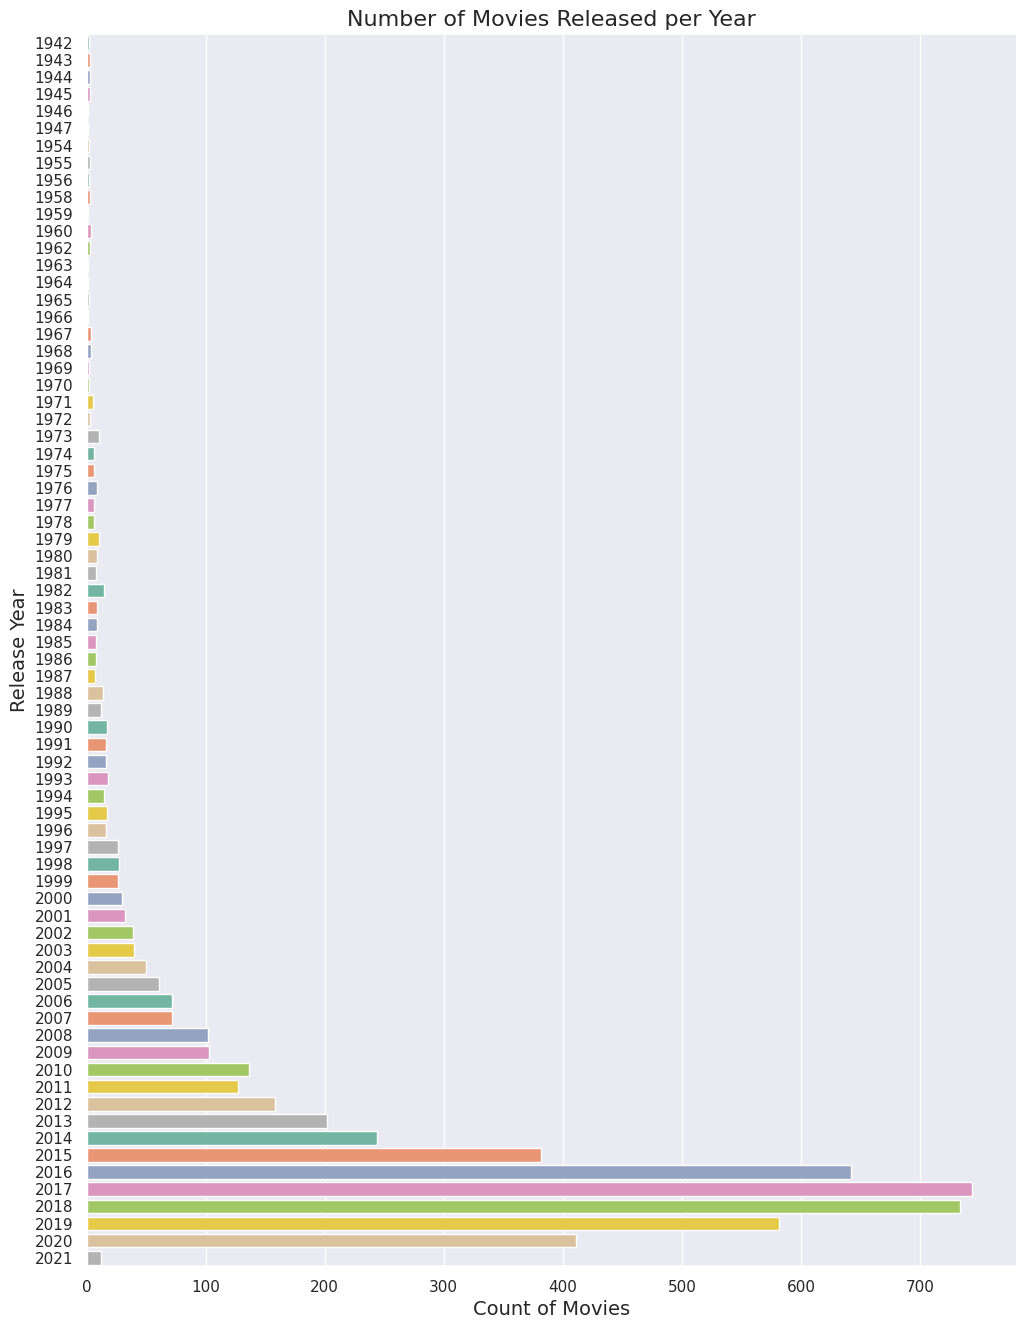

In [8]:
plt.figure(figsize=(12,16))
sns.set(style="darkgrid")

# Countplot for ALL years (sorted by year, not by count)
ax = sns.countplot(
    y="release_year",
    data=netflix_movies,
    palette="Set2",
    order=sorted(netflix_movies['release_year'].unique())  # ensures chronological order
)

plt.title("Number of Movies Released per Year", fontsize=16)
plt.xlabel("Count of Movies", fontsize=14)
plt.ylabel("Release Year", fontsize=14)
plt.show()

#### Duration of Movies

/tmp/ipython-input-1010089188.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_movies['duration'] = netflix_movies['duration'].astype(str)
/tmp/ipython-input-1010089188.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_movies['duration'] = netflix_movies['duration'].str.replace(' min','', regex=False)
/tmp/ipython-input-1010089188.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See

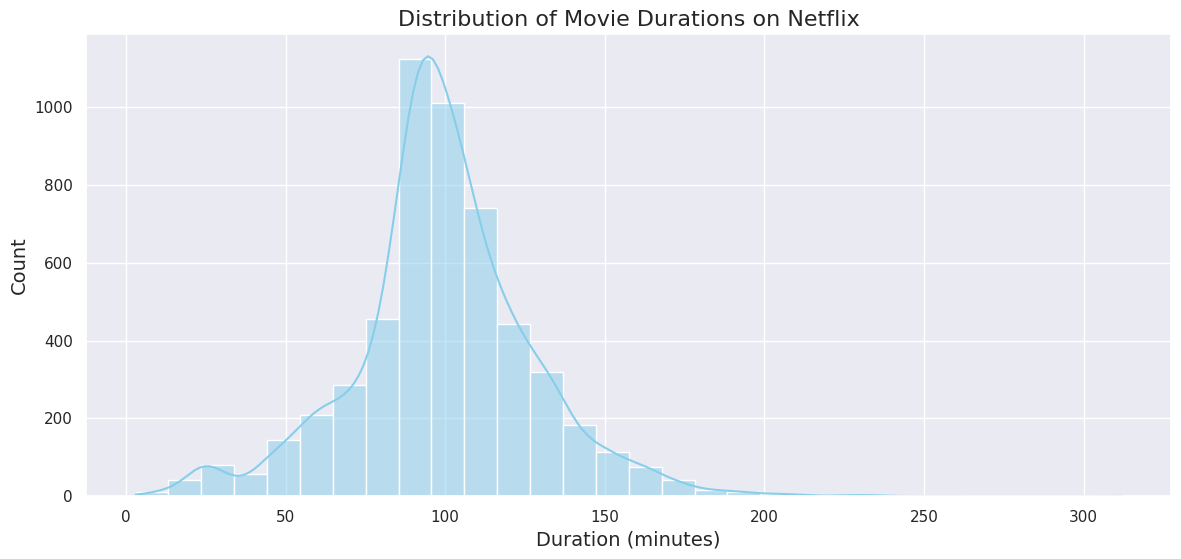

In [9]:
# Convert to string first, handle missing values
netflix_movies['duration'] = netflix_movies['duration'].astype(str)

# Remove the " min" part safely
netflix_movies['duration'] = netflix_movies['duration'].str.replace(' min','', regex=False)

# Convert to numeric (ignores errors like 'nan')
netflix_movies['duration'] = pd.to_numeric(netflix_movies['duration'], errors='coerce')

# Drop rows where duration could not be converted
netflix_movies = netflix_movies.dropna(subset=['duration'])

# Plot histogram
plt.figure(figsize=(14,6))
sns.histplot(netflix_movies['duration'], bins=30, kde=True, color="skyblue")

plt.title("Distribution of Movie Durations on Netflix", fontsize=16)
plt.xlabel("Duration (minutes)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.show()

#### Movie Rating Analysis

/tmp/ipython-input-2648393008.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


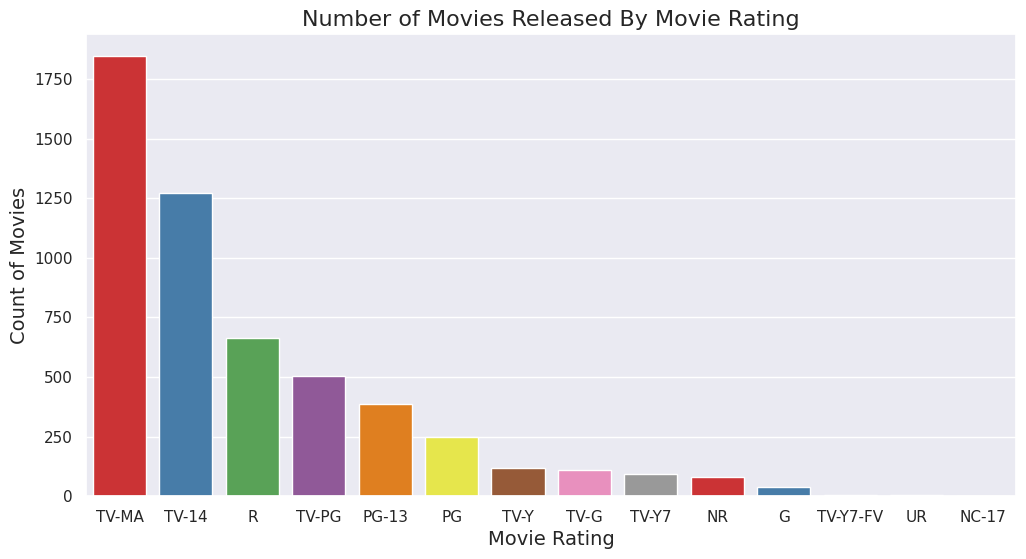

In [10]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    x="rating",
    data=netflix_movies,
    palette="Set1",
    order=netflix_movies['rating'].value_counts().index
)

plt.title("Number of Movies Released By Movie Rating", fontsize=16)
plt.xlabel("Movie Rating", fontsize=14)
plt.ylabel("Count of Movies", fontsize=14)
plt.show()

#### Country Wise Analysis

/tmp/ipython-input-507783360.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


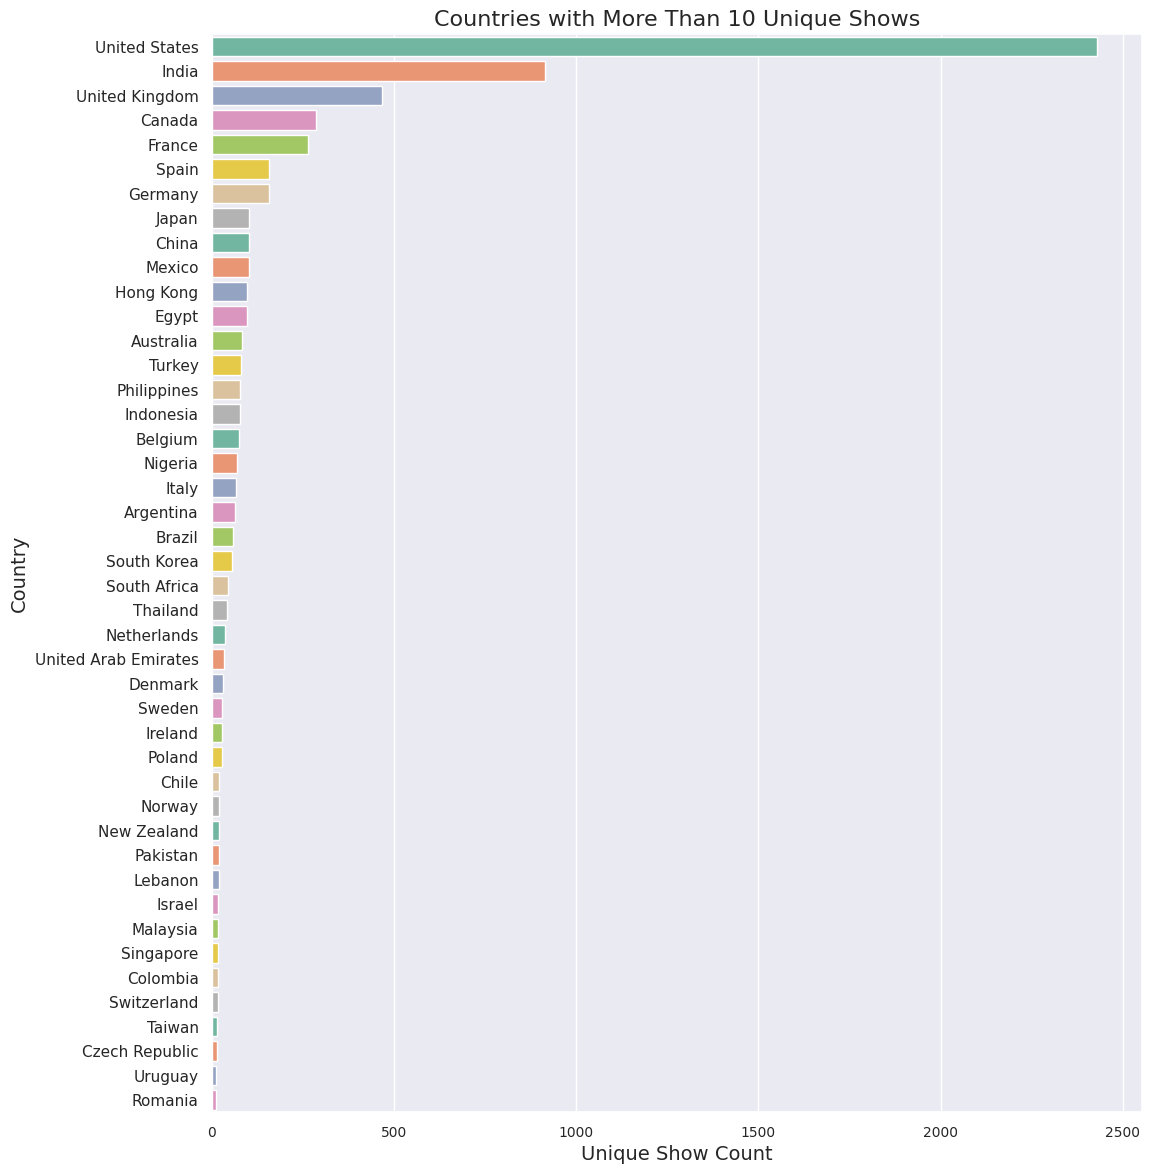

In [11]:
# Split multiple countries and explode into separate rows
netflix_expanded = netflix_movies.assign(
    country=netflix_movies['country'].str.split(', ')
).explode('country').reset_index(drop=True)

# Group by country and count unique show_id
country_unique_counts = netflix_expanded.groupby('country')['show_id'].nunique()

# Filter countries with unique count > 10
country_unique_counts = country_unique_counts[country_unique_counts > 10]

# Sort countries by unique show count descending
country_unique_counts = country_unique_counts.sort_values(ascending=False)

# Plot only top countries
plt.figure(figsize=(12,14))
sns.barplot(
    x=country_unique_counts.values,
    y=country_unique_counts.index,
    palette="Set2"
)
plt.title("Countries with More Than 10 Unique Shows", fontsize=16)
plt.xlabel("Unique Show Count", fontsize=14)
plt.ylabel("Country", fontsize=14)
plt.xticks(fontsize=10)
plt.show()


### Analysis of Netflix TV Shows - Class Activity

In [12]:
netflix_tv_shows = df[df['type']=='TV Show']
netflix_tv_shows

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,0.03,NaN,"Jo√£o Miguel, Bianca Comparato, Michel Gomes, ...",Brazil,2020-08-14 00:00:00,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
5,s6,TV Show,46,Serdar Akar,"Erdal Be≈üik√ßioƒülu, Yasemin Allen, Melis Bir...",Turkey,2017-07-01 00:00:00,2016,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Mysteries",A genetics professor experiments with a treatm...
11,s12,TV Show,1983,NaN,"Robert Wiƒôckiewicz, Maciej Musia≈Ç, Michalina...","Poland, United States",2018-11-30 00:00:00,2018,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Dramas","In this dark alt-history thriller, a na√Øve la..."
12,s13,TV Show,1994,Diego Enrique Osorno,NaN,Mexico,2019-05-17 00:00:00,2019,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...",Archival video and new interviews examine Mexi...
16,s17,TV Show,2025-02-09 00:00:00,NaN,"Shahd El Yaseen, Shaila Sabt, Hala, Hanadi Al-...",NaN,2019-03-20 00:00:00,2018,TV-14,1 Season,"International TV Shows, TV Dramas","As a psychology professor faces Alzheimer's, h..."
...,...,...,...,...,...,...,...,...,...,...,...,...
7767,s7768,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,2016-12-15 00:00:00,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."
7775,s7776,TV Show,Zoids Wild,NaN,"Kensho Ono, Takahiro Sakurai, Mikako Komatsu, ...",Japan,2020-08-14 00:00:00,2018,TV-Y7,1 Season,"Anime Series, Kids' TV",A quest for freedom and legendary treasure beg...
7777,s7778,TV Show,Zombie Dumb,NaN,NaN,NaN,2019-07-01 00:00:00,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
7779,s7780,TV Show,Zona Rosa,NaN,"Manu NNa, Ana Julia Yey√©, Ray Contreras, Pabl...",Mexico,2019-11-26 00:00:00,2019,TV-MA,1 Season,"International TV Shows, Spanish-Language TV Sh...",An assortment of talent takes the stage for a ...


/tmp/ipython-input-3208710986.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


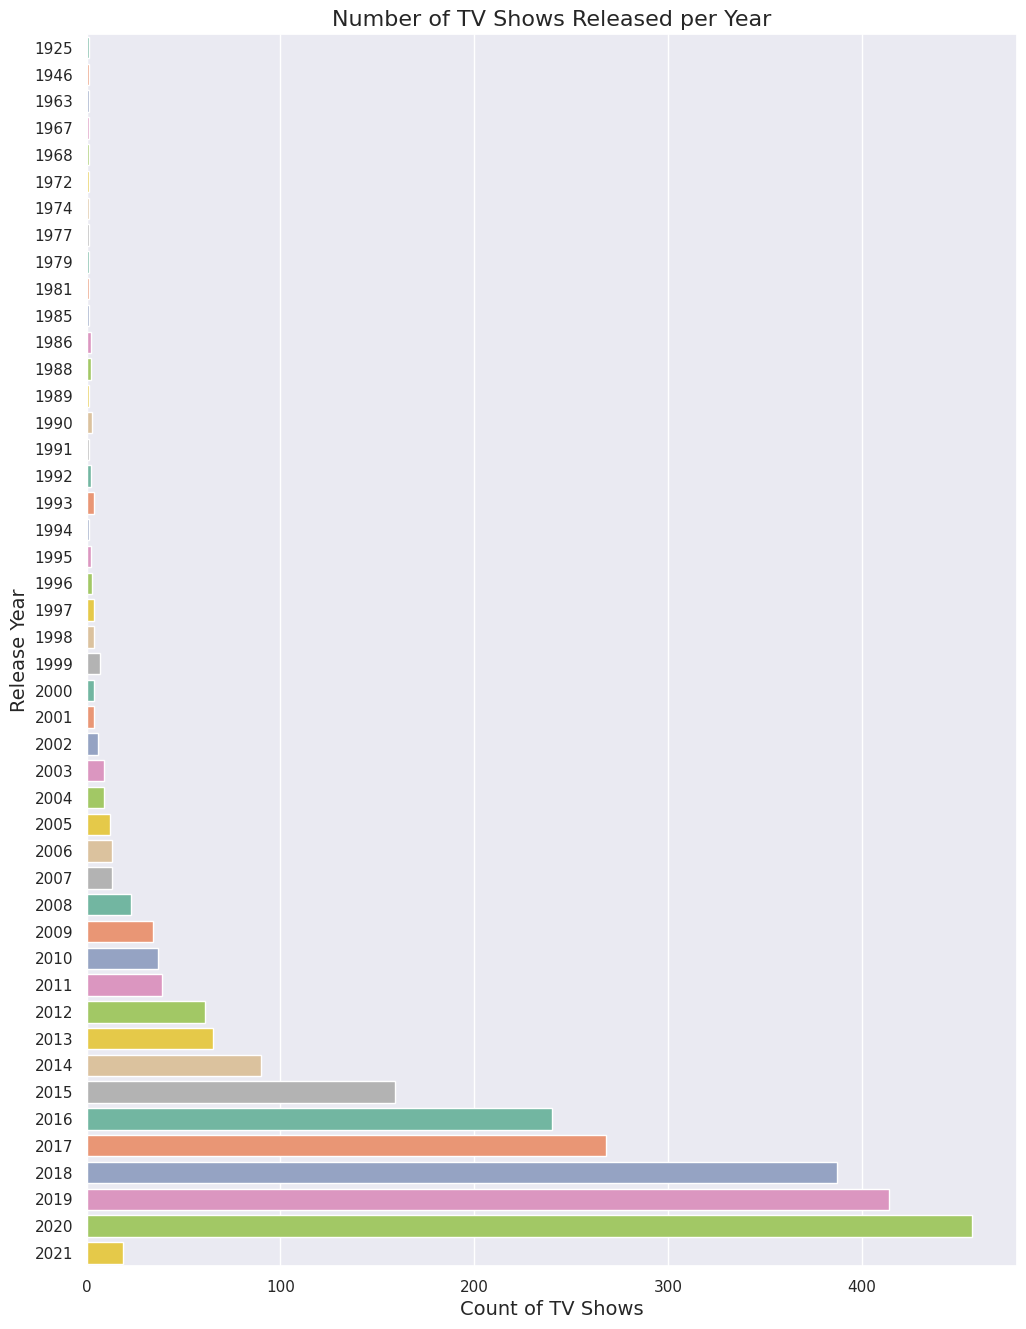

In [13]:
plt.figure(figsize=(12,16))
sns.set(style="darkgrid")

# Countplot for ALL years (sorted by year, not by count)
ax = sns.countplot(
    y="release_year",
    data= netflix_tv_shows,
    palette="Set2",
    order=sorted(netflix_tv_shows['release_year'].unique())  # ensures chronological order
)

plt.title("Number of TV Shows Released per Year", fontsize=16)
plt.xlabel("Count of TV Shows", fontsize=14)
plt.ylabel("Release Year", fontsize=14)
plt.show()

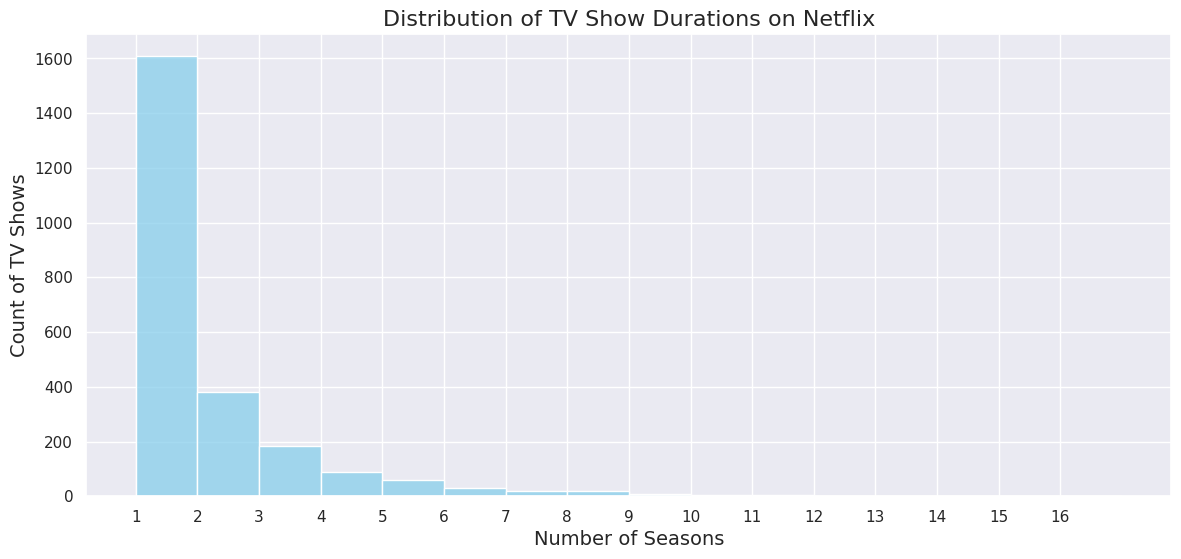

In [16]:
# Convert to string first, handle missing values
netflix_tv_shows['duration'] = netflix_tv_shows['duration'].astype(str)

# Remove the " min" part safely
netflix_tv_shows['duration'] = netflix_tv_shows['duration'].str.replace(' Season','', regex=False)
netflix_tv_shows['duration'] = netflix_tv_shows['duration'].str.replace(' Seasons','', regex=False)


# Convert to numeric (ignores errors like 'nan')
netflix_tv_shows['duration'] = pd.to_numeric(netflix_tv_shows['duration'], errors='coerce')

# Drop rows where duration could not be converted
netflix_tv_shows = netflix_tv_shows.dropna(subset=['duration'])

# Plot histogram
plt.figure(figsize=(14,6))
sns.histplot(
    netflix_tv_shows['duration'],
    bins=range(1, int(netflix_tv_shows['duration'].max())+2),
    color="skyblue"
)

plt.title("Distribution of TV Show Durations on Netflix", fontsize=16)
plt.xlabel("Number of Seasons", fontsize=14)
plt.ylabel("Count of TV Shows", fontsize=14)
plt.xticks(range(1, int(netflix_tv_shows['duration'].max())+1))
plt.show()

/tmp/ipython-input-2236109785.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


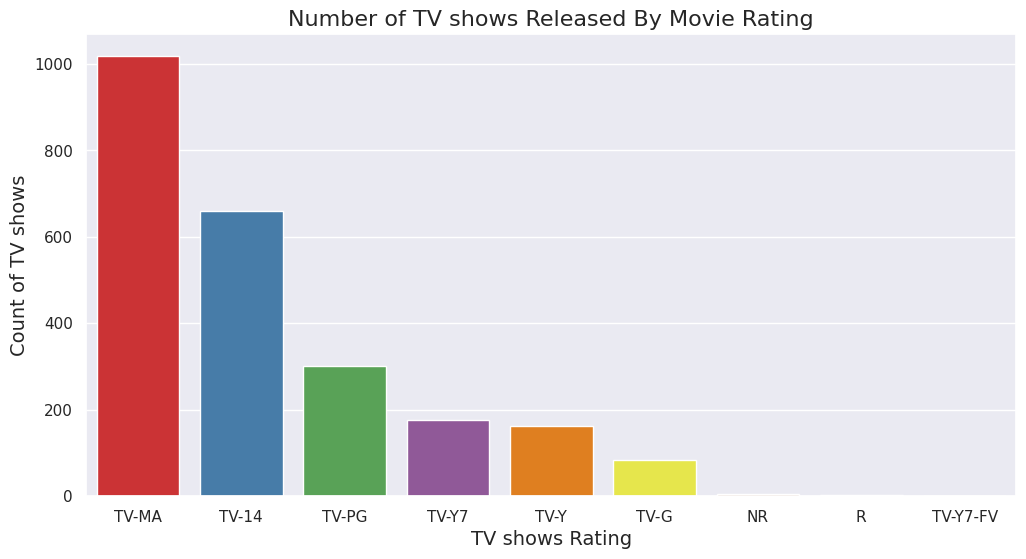

In [17]:

plt.figure(figsize=(12,6))

ax = sns.countplot(
    x="rating",
    data=netflix_tv_shows,
    palette="Set1",
    order=netflix_tv_shows['rating'].value_counts().index
)

plt.title("Number of TV shows Released By Rating", fontsize=16)
plt.xlabel("TV shows Rating", fontsize=14)
plt.ylabel("Count of TV shows", fontsize=14)
plt.show()

In [ ]:
# Split multiple countries and explode into separate rows
netflix_expanded = netflix_tv_shows.assign(
    country=netflix_tv_shows['country'].str.split(', ')
).explode('country').reset_index(drop=True)

# Group by country and count unique show_id
country_unique_counts = netflix_expanded.groupby('country')['show_id'].nunique()

# Filter countries with unique count > 10
country_unique_counts = country_unique_counts[country_unique_counts > 10]

# Sort countries by unique show count descending
country_unique_counts = country_unique_counts.sort_values(ascending=False)

# Plot only top countries
plt.figure(figsize=(12,14))
sns.barplot(
    x=country_unique_counts.values,
    y=country_unique_counts.index,
    palette="Set2"
)
plt.title("Countries with More Than 10 Unique Shows", fontsize=16)
plt.xlabel("Unique Show Count", fontsize=14)
plt.ylabel("Country", fontsize=14)
plt.xticks(fontsize=10)
plt.show()


In [18]:
netflix_tv_shows.shape

(2410, 12)